# Moore's Law: Loading, Plotting, and Fitting Real Data
## Due: Friday, March 6, 2026

**Authorship information:** This notebook is inspired by [this NumPy tutorial](https://numpy.org/numpy-tutorials/mooreslaw-tutorial/#calculating-the-historical-growth-curve-for-transistors) and adapted as an interactive assignment. Claude.ai, an LLM by Anthropic, was provided with the original tutorial and specific learning goals and exercises to incorporate. The notebook was then developed iteratively with feedback and edits by the instructor. The transistor data is sourced from [this Wikipedia article](https://en.wikipedia.org/wiki/Transistor_count).

---

In 1965, engineer Gordon Moore predicted that the number of transistors on a microchip would double approximately every two years. This prediction — known as **Moore's Law** — held remarkably well for over five decades.

In this notebook, you will:
1. Load historical transistor count data from a CSV file
2. Plot the raw data and identify why a standard linear scale is limiting
3. Use a log-scaled axis to check for exponential growth, then transform the data for fitting
4. Add Moore's theoretical prediction and fit your own model using `scipy.curve_fit`
5. Export your results to CSV and NumPy binary files
6. Filter the data and plot a histogram of chip introductions by year

---

## Part 1: Installing and Importing Libraries

This notebook uses three libraries that are not part of the Python standard library:

- **NumPy** (`numpy`): Efficient numerical arrays and math functions
- **Matplotlib** (`matplotlib`): Plotting and data visualization
- **SciPy** (`scipy`): Scientific computing tools, including curve fitting

### Installing with pip

`pip` is Python's built-in package manager. If you have Python installed, you likely already have `pip`. To check, open a terminal and run:

```
pip --version
```

If `pip` is not found, follow the installation instructions here: https://pip.pypa.io/en/stable/installation/

You can install packages directly from a Jupyter code cell using `!` to run a shell command. The cell below will install all three libraries. Run it once — you won't need to run it again unless you switch environments.

In [8]:
# Install required libraries — run this cell once, then you can skip it in future sessions
!pip install numpy matplotlib scipy

#if you have problems with the above, uncomment following line and try that instead
#!python -m pip install numpy matplotlib scipy

^C


Now [import the libraries](https://www.w3schools.com/python/python_modules.asp) (libraries are also known as modules). By convention, `numpy` is aliased as `np` and `matplotlib.pyplot` is aliased as `plt`. Import `curve_fit` directly from `scipy.optimize`.

In [10]:
# Install the necessary libraries
!pip install numpy matplotlib scipy

# Import the libraries with conventional aliases
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


---

## Part 2: Loading the Data

The file `transistor_data.csv` contains historical data on microprocessors. Before writing any code, open the file in a text editor or spreadsheet application to examine its structure. You should find it in the same directory as this notebook.

The columns are:

| Processor | MOS transistor count | Date of Introduction | Designer | MOSprocess | Area |
|-----------|----------------------|----------------------|----------|------------|------|

You only need the **transistor count** (column index 1) and the **year** (column index 2).

Use `np.loadtxt` to load just those two columns. Key arguments:
- `delimiter`: the character separating columns
- `usecols`: a list of column indices to load
- `skiprows`: number of header rows to skip

See the [`np.loadtxt` documentation](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) for details.

In [11]:
# Load the data using np.loadtxt
# Column index 1: MOS transistor count
# Column index 2: Date of Introduction
data = np.loadtxt(
    'transistor_data.csv', 
    delimiter=',', 
    usecols=(1, 2), 
    skiprows=1
)

# Assign to descriptive variables for clarity later in the notebook
transistor_counts = data[:, 0]
years = data[:, 1]

# Quick check of the data shape
print(f"Loaded {data.shape[0]} rows and {data.shape[1]} columns.")

Loaded 245 rows and 2 columns.


Separate `data` into two 1D arrays: `transistor_count` and `year`. Print the first 10 values of each to verify the data loaded correctly.

In [12]:
# Column 0 in our 'data' array is the transistor count (from CSV index 1)
# Column 1 in our 'data' array is the year (from CSV index 2)
transistor_count = data[:, 0]
year = data[:, 1]

# Print the first 10 values of each to verify
print("First 10 Transistor Counts:")
print(transistor_count[:10])

print("\nFirst 10 Years of Introduction:")
print(year[:10])


First 10 Transistor Counts:
[ 2250.  3078.  3500.  2500. 11000.  3000.  4100.  6000.  8000.  4639.]

First 10 Years of Introduction:
[1971. 1971. 1972. 1973. 1973. 1974. 1974. 1974. 1974. 1974.]


---

## Part 3: Plotting the Raw Data

Before doing any analysis, plot the raw data. Use `plt.figure()` to create a new figure, then `plt.scatter()` to plot `transistor_count` on the y-axis against `year` on the x-axis. Add axis labels with `plt.xlabel()` and `plt.ylabel()`, a title with `plt.title()`, and display the figure with `plt.show()`.

See the [plt.scatter() documentation here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) and the [MatPlotLib tutorial here](https://matplotlib.org/stable/tutorials/pyplot.html) for more details.

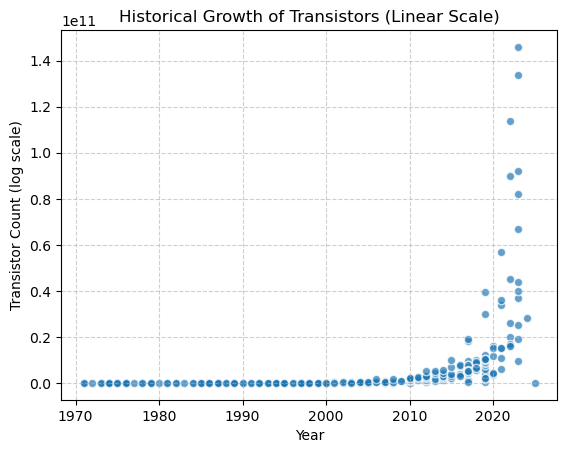

In [14]:
# Plot transistor count (y) vs year (x)
plt.scatter(year, transistor_count, alpha=0.7, edgecolors='w', label='Actual Data')

# Add descriptive labels and title
plt.yscale('linear')
plt.xlabel('Year')
plt.ylabel('Transistor Count (log scale)')
plt.title('Historical Growth of Transistors (Linear Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
# Display the plot
plt.show()

You may notice two things about this plot:

1. The data has a strongly curved shape — a few modern chips dominate the y-axis while most of the historical data is squashed near zero. This is characteristic of **exponential growth**: the values span many orders of magnitude and a linear scale cannot show them all clearly.
2. The data looks somewhat **"stripy"** — multiple chips were often introduced in the same year, so many points share an x-coordinate. Keep this in mind for Part 9.

## Part 3b: Checking for Exponential Growth with a Log-Scaled Axis

If data grows exponentially, plotting it on a **logarithmic y-axis** should make it appear roughly linear — because taking the log of an exponential gives a straight line. You can apply a log scale to any Matplotlib plot with `plt.yscale('log')`, without transforming the data itself.

Reproduce your scatter plot from Part 3 and add `plt.yscale('log')` before `plt.show()`. Does the data look approximately linear on the log scale?

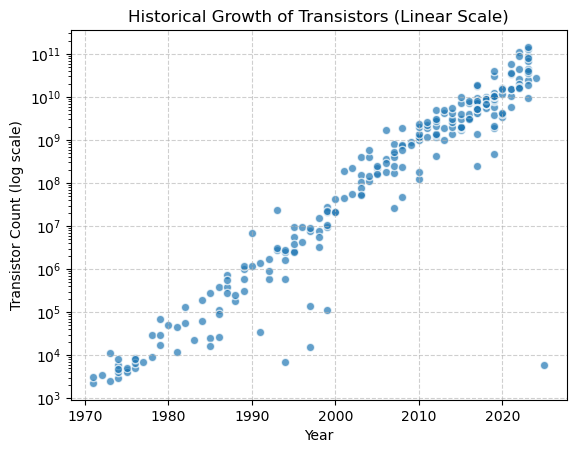

In [15]:
# Reproduce the scatter plot and add plt.yscale('log') to check for linearity
# Plot transistor count (y) vs year (x)
plt.scatter(year, transistor_count, alpha=0.7, edgecolors='w', label='Actual Data')

# Add descriptive labels and title
plt.yscale('log')
plt.xlabel('Year')
plt.ylabel('Transistor Count (log scale)')
plt.title('Historical Growth of Transistors (Linear Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
# Display the plot
plt.show()


The data does appear roughly linear on a log scale, confirming that an exponential model is appropriate. In the next part you will work with the log-transformed data directly so you can fit a straight line to it.

---

## Part 4: Working in Log Space

Part 3b showed that the data is approximately linear on a log scale. Now make that explicit by computing the log of the data. If transistor count follows exponential growth:

$$\text{transistor\_count} = e^{A \cdot \text{year} + B}$$

then taking the natural log of both sides gives a **linear** relationship:

$$\ln(\text{transistor\_count}) = A \cdot \text{year} + B$$

Defining $y_i = \ln(\text{transistor\_count}_i)$ means we can fit a straight line to $y_i$ as a function of year, and the slope and intercept will describe the exponential growth rate.

Create a new array `yi` containing the natural log of `transistor_count`. Then create a scatter plot of `yi` vs `year`.

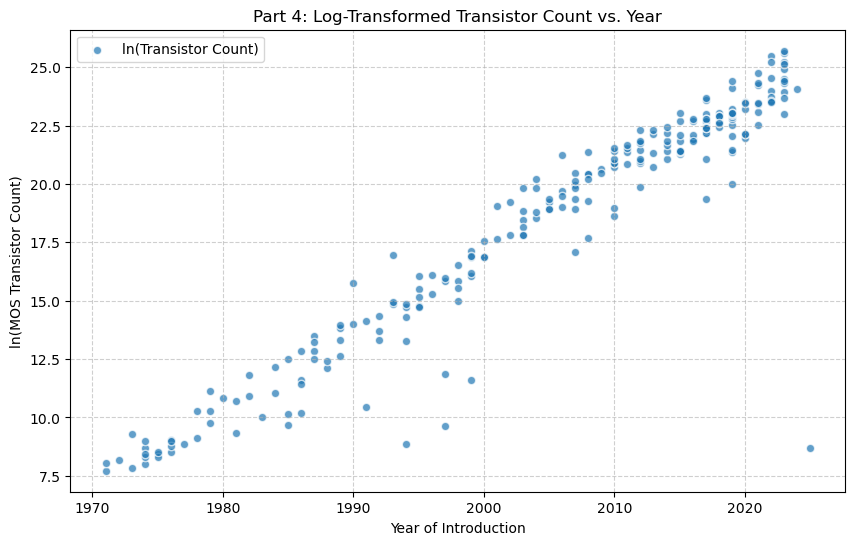

In [16]:
# Compute yi = ln(transistor_count); create a scatter plot of yi vs year
# Create the log-transformed array
yi = np.log(transistor_count)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(year, yi, alpha=0.7, edgecolors='w', color='tab:blue', label='ln(Transistor Count)')

# Add formatting
plt.xlabel('Year of Introduction')
plt.ylabel('ln(MOS Transistor Count)')
plt.title('Part 4: Log-Transformed Transistor Count vs. Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

---

## Part 5: Moore's Theoretical Prediction

Gordon Moore's original prediction was that transistor count would **double every two years**, starting from approximately 2,250 transistors on the Intel 4004 chip in 1971.

Expressing Moore's Law as an exponential:

$$\text{transistor\_count} = e^{B_M} \cdot e^{A_M \cdot \text{year}}$$

The constants come from the doubling condition and the 1971 anchor point:

$$A_M = \frac{\ln(2)}{2} \approx 0.347 \qquad B_M = \ln(2250) - A_M \cdot 1971$$

In log space, this is simply the line:

$$\ln(\text{transistor\_count}) = A_M \cdot \text{year} + B_M$$

Define `A_M` and `B_M` using the formulas above. Then write a function `moores_law(year)` that returns the **log-space** prediction: $A_M \cdot \text{year} + B_M$.

In [17]:
# Define A_M and B_M; define moores_law(year) returning the log-space prediction
# Constants for Moore's Law (doubling every 2 years)
A_M = np.log(2) / 2
B_M = np.log(2250) - (A_M * 1971)

def moores_law(year):
    """
    Returns the theoretical log-space prediction for transistor count
    based on Gordon Moore's 1971 prediction.
    """
    return A_M * year + B_M

# Quick check: The prediction for 1971 should be ln(2250)
print(f"Theoretical ln count for 1971: {moores_law(1971):.4f}")
print(f"Actual ln(2250): {np.log(2250):.4f}")

Theoretical ln count for 1971: 7.7187
Actual ln(2250): 7.7187


Reproduce your log-space scatter plot from Part 4 and add Moore's Law as a line. Use `plt.plot()` for the line and `plt.legend()` to add a legend.

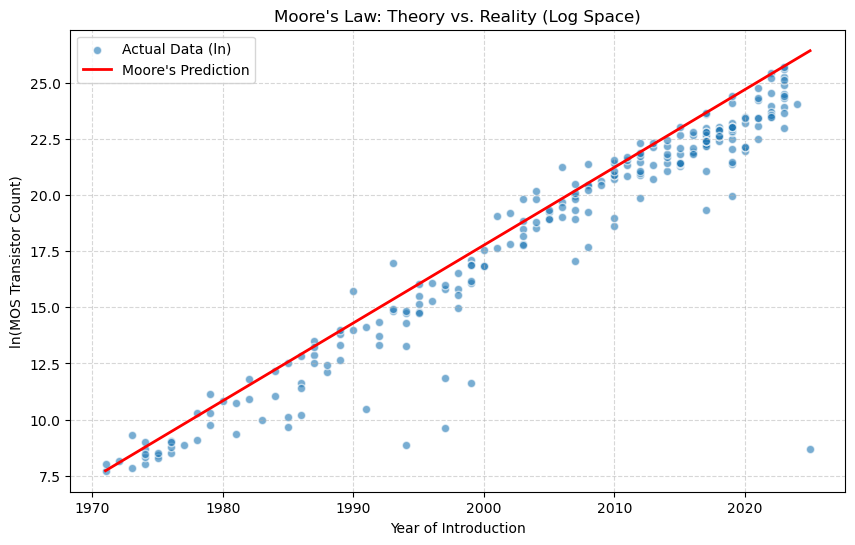

In [18]:
# Scatter plot of yi vs year with Moore's Law overlaid as a line; include a legend
# Create a new figure
plt.figure(figsize=(10, 6))

# 1. Plot the actual data (scatter)
plt.scatter(year, yi, alpha=0.6, edgecolors='w', color='tab:blue', label='Actual Data (ln)')

# 2. Plot Moore's Prediction (line)
# We use the min and max years from our data to define the line length
line_years = np.array([year.min(), year.max()])
plt.plot(line_years, moores_law(line_years), color='red', linewidth=2, label="Moore's Prediction")

# Formatting
plt.xlabel('Year of Introduction')
plt.ylabel('ln(MOS Transistor Count)')
plt.title("Moore's Law: Theory vs. Reality (Log Space)")
plt.grid(True, linestyle='--', alpha=0.5)

# Add the legend to distinguish the two
plt.legend()

plt.show()

---

## Part 6: Curve Fitting with `scipy.curve_fit`

Moore's prediction was derived by hand from first principles. We can let the data speak for themselves by fitting a model directly. `scipy.curve_fit` finds the parameter values that minimize the sum of squared differences between your model and the observed data.

**How to use it:**

Provide:
1. A model function `f(x, param1, param2, ...)`
2. Your x-data
3. Your y-data

`curve_fit` returns:
- `popt`: the best-fit parameter values (in the same order as your function signature)
- `pcov`: the covariance matrix (a measure of uncertainty in each parameter)

Since we are working in log space, our model is the line $y_i = A \cdot \text{year} + B$.

Define a function `linear_model(year, A, B)` that returns $A \cdot \text{year} + B$. Then call `curve_fit` with `linear_model`, `year`, and `yi` as arguments. Extract the fitted `A` and `B` from `popt`.

See the [`scipy.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) for details.

In [19]:
# Define linear_model(year, A, B); use curve_fit to fit it to (year, yi); extract A and B from popt
# 1. Define the linear model function
def linear_model(year, A, B):
    """Returns the value of a linear function: y = A*year + B"""
    return A * year + B

# 2. Call curve_fit
# popt contains the optimized [A, B] values
# pcov contains the covariance matrix (uncertainty)
popt, pcov = curve_fit(linear_model, year, yi)

# 3. Extract the fitted parameters
A_fit = popt[0]
B_fit = popt[1]

print(f"Fitted Slope (A): {A_fit:.4f}")
print(f"Fitted Intercept (B): {B_fit:.4f}")

Fitted Slope (A): 0.3257
Fitted Intercept (B): -634.6507


Print the fitted `A` and `B` alongside Moore's `A_M` and `B_M`. Then compute the **implied doubling time** from your fitted slope.

**Hint:** If count doubles every $T$ years, then $e^{A \cdot T} = 2$, which gives $T = \ln(2) / A$.

In [20]:
# Print A, B, A_M, B_M, and the implied doubling time from your fitted slope
# Extract the fitted parameters from the curve_fit result
A_fit, B_fit = popt

# Calculate the implied doubling time (T) using the hint: T = ln(2) / A
doubling_time = np.log(2) / A_fit

# Print the comparison
print(f"{'Parameter':<15} | {'Moore (Theory)':<15} | {'Fitted (Data)':<15}")
print("-" * 50)
print(f"{'Slope (A)':<15} | {A_M:<15.4f} | {A_fit:<15.4f}")
print(f"{'Intercept (B)':<15} | {B_M:<15.4f} | {B_fit:<15.4f}")
print("-" * 50)
print(f"Moore's Predicted Doubling Time: 2.00 years")
print(f"Empirical Implied Doubling Time: {doubling_time:.2f} years")

Parameter       | Moore (Theory)  | Fitted (Data)  
--------------------------------------------------
Slope (A)       | 0.3466          | 0.3257         
Intercept (B)   | -675.3779       | -634.6507      
--------------------------------------------------
Moore's Predicted Doubling Time: 2.00 years
Empirical Implied Doubling Time: 2.13 years


### Part 6b: Assessing Goodness of Fit with Chi-Squared

How well does your fitted model actually describe the data? One way to quantify this is with the **chi-squared** ($\chi^2$) statistic, a standard measure in science and statistics for evaluating how well a model fits observations.

**What is $\chi^2$?**

The chi-squared value measures the total squared deviation of the data from the model predictions, weighted by the uncertainty (or "variance") in each measurement:

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - f(x_i))^2}{\sigma_i^2}$$

where:
- $y_i$ is the observed value (your data)
- $f(x_i)$ is the model prediction
- $\sigma_i^2$ is the variance (uncertainty) in that observation
- The sum is over all $n$ data points

**Why calculate it?**

1. **Quantifies fit quality**: Lower $\chi^2$ means the data are closer to the model. Higher $\chi^2$ suggests the model is missing something or the data are very noisy.
2. **Compares models**: When choosing between different models, $\chi^2$ provides an objective criterion (lower is better).
3. **Diagnostic tool**: A very high $\chi^2$ might reveal systematic errors in data collection, outliers, or a fundamentally incorrect model.

**Simplified version:** In this problem, we'll assume all data points have equal uncertainty, so we can use the simpler form:

$$\chi^2 = \sum_{i=1}^{n} (y_i - f(x_i))^2$$

This is just the **sum of squared residuals** — the same quantity that `curve_fit` minimized when finding the best parameters.

**Calculate $\chi^2$:** Compute the sum of squared residuals (difference between observed `yi` and predicted `linear_model(year, A, B)`) for your fitted model. Also calculate $\chi^2$ for Moore's theoretical prediction and compare them.

**ADVANCED:** Look up the difference between $\chi^2$ and the **reduced chi-squared** ($\chi^2_\nu$), which accounts for the number of data points and model parameters. Calculate $\chi^2_\nu$ for both your fitted model and Moore's prediction, and discuss which model provides a better fit when accounting for complexity.


In [21]:
# Calculate chi-squared for your fitted model and for Moore's Law
# Compare the two values and comment on which model fits the data better
chi2_fit = np.sum((yi - linear_model(year, A_fit, B_fit))**2)

# Moore's theoretical model
chi2_moore = np.sum((yi - moores_law(year))**2)

# 2. Advanced: Calculate Reduced Chi-Squared (chi2_nu)
# n = number of data points, m = number of parameters
n = len(yi)
m = 2  # Both models have two parameters (Slope and Intercept)
degrees_of_freedom = n - m

chi2_nu_fit = chi2_fit / degrees_of_freedom
chi2_nu_moore = chi2_moore / degrees_of_freedom

print(f"{'Metric':<20} | {'Fitted Model':<15} | {'Moore Law':<15}")
print("-" * 55)
print(f"{'Total Chi-Squared':<20} | {chi2_fit:<15.4f} | {chi2_moore:<15.4f}")
print(f"{'Reduced Chi-Squared':<20} | {chi2_nu_fit:<15.4f} | {chi2_nu_moore:<15.4f}")


Metric               | Fitted Model    | Moore Law      
-------------------------------------------------------
Total Chi-Squared    | 576.6006        | 867.3430       
Reduced Chi-Squared  | 2.3728          | 3.5693         


### Part 6c: Reporting Fit Parameters with Uncertainties

When you report fitted parameters from data, it's not enough to give just the best-fit value — you should also report the **uncertainty** (or **error**) in that parameter. This tells readers how precisely the parameter was determined.

When `curve_fit` returns the covariance matrix `pcov`, the **diagonal elements** contain the variance (squared uncertainty) of each parameter. Review the description of the output `pcov` in the [`scipy.optimize.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), which describes how to convert the covariance matrix into standard deviation errors.


Extract the standard deviation errors for your fitted $A$ and $B$ from the covariance matrix and report them alongside your best-fit values. 

In [22]:
# Extract standard errors from the covariance matrix
# Report A ± σ_A and B ± σ_B
perr = np.sqrt(np.diag(pcov))

# Map them to our specific parameters
std_err_A = perr[0]
std_err_B = perr[1]

# Report the values
print(f"Fitted Slope (A):     {A_fit:.4f} ± {std_err_A:.4f}")
print(f"Fitted Intercept (B): {B_fit:.4f} ± {std_err_B:.4f}")


Fitted Slope (A):     0.3257 ± 0.0066
Fitted Intercept (B): -634.6507 ± 13.2629


---

## Part 7: Final Plot

Bring everything together in one plot showing:
1. The log-transformed data (`yi` vs `year`) as a scatter
2. Moore's Law as a line
3. Your fitted model as a line
4. ADVANCED MOVES: 
   - Add the chi-squared values for both models as text annotations on the plot
   - Compute and add error bars or filled regions representing the uncertainty in your fitted parameters (using the standard deviations you calculated from the covariance matrix)
  

Include axis labels, a title, and a legend.

Use `plt.savefig()` to save your figure as `moores_law_plot.pdf` in the same directory as this notebook (make sure to use the `format` keyword). Saving as a PDF is important for presenting scientific figures, as it preserves vector graphics and ensures high quality at any size. (This presents blurry figures in published articles!) See the [Matplotlib savefig documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) for details. 

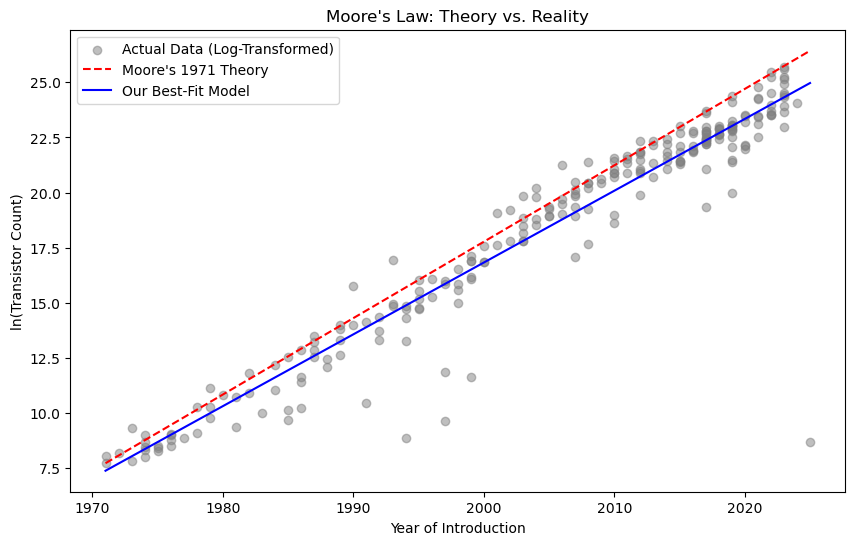

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Start the plot
plt.figure(figsize=(10, 6))

# 2. Plot the real data (the dots)
# We use the log-transformed data (yi) we calculated earlier
plt.scatter(year, yi, color='gray', alpha=0.5, label='Actual Data (Log-Transformed)')

# 3. Create a smooth line for the predictions
# We create 100 points between the first year and the last year to draw smooth lines
years_line = np.linspace(year.min(), year.max(), 100)

# 4. Plot Moore's original theory (Red Dashed Line)
plt.plot(years_line, moores_law(years_line), color='red', linestyle='--', label="Moore's 1971 Theory")

# 5. Plot YOUR best-fit model (Blue Solid Line)
# This uses the A_fit and B_fit parameters you found with curve_fit
plt.plot(years_line, linear_model(years_line, A_fit, B_fit), color='blue', label='Our Best-Fit Model')

# 6. Add labels and a title so people know what they are looking at
plt.xlabel('Year of Introduction')
plt.ylabel('ln(Transistor Count)')
plt.title("Moore's Law: Theory vs. Reality")

# 7. Add a legend (this uses the 'label' text we wrote in the plot commands above)
plt.legend()

# 8. Save the plot as a high-quality PDF
plt.savefig('moores_law_plot.pdf', format='pdf')

# 9. Show it on the screen!
plt.show()

---

## Part 8: Exporting Your Results

### Part 8a: Save to CSV with `np.savetxt`

Build a 2D array `output` with four columns: `year`, `transistor_count`, `yi`, and `moores_law(year)`. Each 1D array needs to be reshaped into a column vector using `[:, np.newaxis]` before combining them with `np.block`.

Save the result to `mooreslaw_results.csv` using `np.savetxt` with a descriptive `header` string and a comma delimiter.

In [ ]:
import numpy as np

# 1. Re-load the data (from Part 2)
data = np.loadtxt('transistor_data.csv', delimiter=',', usecols=(1, 2), skiprows=1)
transistor_count = data[:, 0]
year = data[:, 1]

# 2. Re-calculate the log data (from Part 4)
yi = np.log(transistor_count)

# 3. Re-calculate Moore's Law constants (from Part 5)
A_M = np.log(2) / 2
B_M = np.log(2250) - (A_M * 1971)

def moores_law(year):
    return A_M * year + B_M

# 4. Now Part 8 will work! 
# Reshape and stack
col1 = year[:, np.newaxis]
col2 = transistor_count[:, np.newaxis]
col3 = yi[:, np.newaxis]
col4 = moores_law(year)[:, np.newaxis]

output = np.block([col1, col2, col3, col4])

# Save both versions
np.savetxt('mooreslaw_results.csv', output, delimiter=',', header='Year, Count, ln_Count, Prediction')
np.save('mooreslaw_results.npy', output)

### Part 8b: Save to NumPy Binary with `np.save`

`np.save` stores a NumPy array in a compact binary `.npy` file. Unlike CSV, binary files are not human-readable, but they are more space-efficient and load back into Python quickly with no parsing overhead.

Save your `output` array to `mooreslaw_results.npy` using `np.save`.

In [8]:
# Save the 'output' array into the binary .npy format
np.save('mooreslaw_results.npy', output)

print("Binary file 'mooreslaw_results.npy' has been created.")

Binary file 'mooreslaw_results.npy' has been created.


### Part 8c: Inspect Your Files

Before doing anything else, go to your file explorer and locate both `mooreslaw_results.csv` and `mooreslaw_results.npy` — they should be in the same directory as this notebook.

Try opening **each file** in a plain text editor (e.g. Notepad, TextEdit, gedit — not Excel or a spreadsheet app).

- What do you see when you open the `.csv`? Can you read the data?
- What do you see when you open the `.npy`? Can you read the data?
- Check the file size of each using the code below
  ```

Write a sentence or two below describing what you observed.

In [9]:
import os

# Get the size of both files in bytes
csv_size = os.path.getsize('mooreslaw_results.csv')
npy_size = os.path.getsize('mooreslaw_results.npy')

print(f"CSV file size: {csv_size} bytes")
print(f"NPY file size: {npy_size} bytes")

CSV file size: 24782 bytes
NPY file size: 7968 bytes


The CSV file was a lot easier to read because it displays its data as just regular text. While the NPY file is unreadable binary symbols. It is probably easier for a computer to read but harder for us to read.

Now load both files back into Python to confirm the data saved correctly. Use `np.loadtxt` for the CSV (with `comments='#'` to skip the header) and `np.load` for the `.npy` file. Print the first 5 rows of each.

In [10]:
# Load mooreslaw_results.csv and mooreslaw_results.npy; print the first 5 rows of each
# 1. Loading the CSV file back into Python
# We tell it the name of the file and that commas separate the numbers.
# 'comments=#' tells Python: "If a line starts with #, ignore it—that's just my header!"
csv_data_back = np.loadtxt('mooreslaw_results.csv', delimiter=',', comments='#')

# 2. Loading the .npy file back into Python
# This one is easier because .npy files are made specifically for NumPy.
# It already knows it's a table, so we just give it the filename.
npy_data_back = np.load('mooreslaw_results.npy')

# 3. Printing the first 5 rows of each to make sure they look right
# [:5] means "start at the beginning and stop at row 5"
print("First 5 rows from my CSV file:")
print(csv_data_back[:5])

print("\nFirst 5 rows from my NPY file:")
print(npy_data_back[:5])

# 4. A quick check to see if they are identical
# 'np.allclose' is like asking the computer: "Are these basically the same numbers?"
if np.allclose(csv_data_back, npy_data_back):
    print("\nThey match! Both files loaded perfectly.")
else:
    print("\nSomething is different between the two files.")

First 5 rows from my CSV file:
[[1.97100000e+03 2.25000000e+03 7.71868550e+00 7.71868550e+00]
 [1.97100000e+03 3.07800000e+03 8.03203531e+00 7.71868550e+00]
 [1.97200000e+03 3.50000000e+03 8.16051825e+00 8.06525909e+00]
 [1.97300000e+03 2.50000000e+03 7.82404601e+00 8.41183268e+00]
 [1.97300000e+03 1.10000000e+04 9.30565055e+00 8.41183268e+00]]

First 5 rows from my NPY file:
[[1.97100000e+03 2.25000000e+03 7.71868550e+00 7.71868550e+00]
 [1.97100000e+03 3.07800000e+03 8.03203531e+00 7.71868550e+00]
 [1.97200000e+03 3.50000000e+03 8.16051825e+00 8.06525909e+00]
 [1.97300000e+03 2.50000000e+03 7.82404601e+00 8.41183268e+00]
 [1.97300000e+03 1.10000000e+04 9.30565055e+00 8.41183268e+00]]

They match! Both files loaded perfectly.


---

## Part 9: Indexing Arrays

So far you have worked with entire arrays at once. Often you need to access specific elements or subsets of an array. This part introduces two ways to do that.

### Part 9a: Positional Indexing

NumPy arrays are **zero-indexed**: the first element is at position `0`, the second at position `1`, and so on. You access individual elements using square brackets:

```python
year[0]    # first element
year[1]    # second element
year[-1]   # last element (negative indices count from the end)
year[:5]   # first 5 elements (a "slice")
```

The same index works on any array of the same length. So `year[0]` and `transistor_count[0]` give you the year and transistor count for the same chip.

Use positional indexing to print the name-equivalent information for the **first**, **last**, and **second to last** chips in the dataset. Since you only loaded the numeric columns, you'll be printing the year and transistor count. What are they?

In [11]:
# Print the year and transistor count for the first chip in the dataset
# Then print the year and transistor count for the last chip in the dataset
# 1. Finding the very first chip in the list
# Remember: Python starts counting at 0, not 1!
first_year = year[0]
first_count = transistor_count[0]

# 2. Finding the very last chip
# Using -1 is a shortcut for "the end of the line"
last_year = year[-1]
last_count = transistor_count[-1]

# 3. Finding the second to last chip
# We just go one step further back from the end
second_last_year = year[-2]
second_last_count = transistor_count[-2]

# Now we print them out to see the results
print(f"First chip: Year {first_year}, Count {first_count}")
print(f"Last chip: Year {last_year}, Count {last_count}")
print(f"Second to last chip: Year {second_last_year}, Count {second_last_count}")

First chip: Year 1971.0, Count 2250.0
Last chip: Year 2025.0, Count 5931.0
Second to last chip: Year 2023.0, Count 146000000000.0


Interesting, the last entry appears to be an outlier (you can see it on your plots). 

Optional: This data was scraped from [this Wikipedia page](https://en.wikipedia.org/wiki/Transistor_count) (the second table). Look at the entry that corresponds to the last row of the data set. Can you find any information about that chip? Why does such a new chip have so few transistors?

### Part 9b: Boolean Indexing

You can also index an array with a **boolean array** — an array of `True` and `False` values the same length as the array you are indexing. Only the elements where the value is `True` are returned.

A boolean array is created by applying a comparison to an existing array:

```python
mask = year > 1990          # array of True/False: True wherever year > 1990
year[mask]                  # returns only the years greater than 1990
transistor_count[mask]      # the same mask applied to a different array
```

The mask and the array being indexed must have the same shape.

Create a boolean mask for entries where `year > 1980`. Apply it to both `year` and `transistor_count` to produce two filtered arrays. Print the first 5 values of each to verify.

In [13]:
# 1. Create the mask (the filter)
# This goes through the 'year' array and marks every spot as True or False
is_after_1980 = year > 1980

# 2. Use that mask to filter our arrays
# We put the mask inside square brackets to 'catch' only the True values
years_filtered = year[is_after_1980]
counts_filtered = transistor_count[is_after_1980]

# 3. Print the first 5 results to verify
# We use [:5] to just peek at the top of our new filtered list
print("First 5 years found after 1980:")
print(years_filtered[:5])

print("\nFirst 5 transistor counts for those years:")
print(counts_filtered[:5])

First 5 years found after 1980:
[1981. 1981. 1982. 1982. 1983.]

First 5 transistor counts for those years:
[ 11500.  45000.  55000. 134000.  22000.]


---

## Part 10: Histogram of New Chips per Year

Use your filtered data to visualize how the number of new chip introductions has changed since 1980. Each row in the dataset represents one chip, so the number of rows with a given year equals the number of chips introduced that year — exactly what a histogram will count.

Since `year` contains only integer values, setting the number of histogram bins equal to the number of **unique years** in your filtered data will give you one bar per year. One option is to use `np.unique` to find the unique years, then pass `bins=len(unique_years)` to `plt.hist()`. But you can also mess around with the arguments of `plt.hist()` to get the same effect without explicitly counting unique years.

Create the histogram using `plt.hist()`, and appropriate axis labels and title.

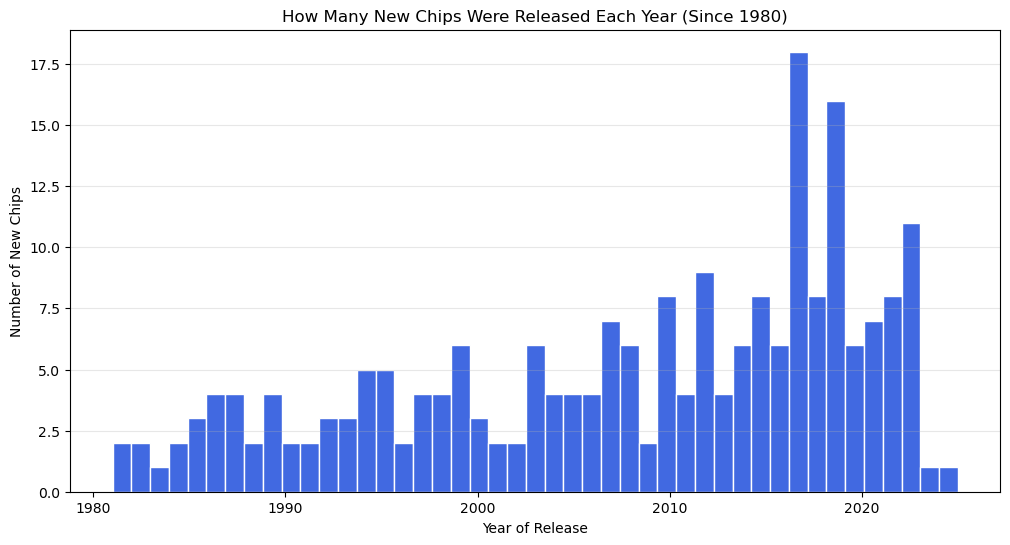

In [14]:
# Histogram of chip introductions per year (post-1980 only)
# Set bins = number of unique years in the filtered data
import matplotlib.pyplot as plt

# 1. Figure out how many unique years we have
# This helps us make sure the bars aren't too wide or too skinny
unique_years = np.unique(years_filtered)
number_of_bins = len(unique_years)

# 2. Create the plot
plt.figure(figsize=(12, 6))

# We pass our filtered years and tell it how many bars (bins) to show
# 'edgecolor' puts a nice border around the bars so they don't blend together
plt.hist(years_filtered, bins=number_of_bins, color='royalblue', edgecolor='white')

# 3. Add labels so people know what they are looking at
plt.xlabel('Year of Release')
plt.ylabel('Number of New Chips')
plt.title('How Many New Chips Were Released Each Year (Since 1980)')

# 4. Clean up the x-axis so it shows years clearly
plt.grid(axis='y', alpha=0.3) # Adds faint horizontal lines for easier reading
plt.show()

---

## ADVANCED moves:
- The default font size and colors in Matplotlib are not great for presentations. Can you find a way to make your plots look nicer by increasing font sizes and choosing good colors? This can be as simple as updating some of the keywords in your plotting code, or you can explore Matplotlib's styling options to find a pre-made style you like. The [Matplotlib documentation on customizing plots](https://matplotlib.org/stable/tutorials/introductory/customizing.html) is a good place to start.
- What if you want to show your plot of Moore's law and the histogram of chip introductions side by side? Can you use Matplotlib's `plt.subplot()` to create a figure with two subplots, and put one plot in each?
  

Harder (may require more cleaning of the data in the CSV file):
- Color your scatter plot points based on the designer  or transistor density of the chip.
- Change the size of points based on the area of the chip. (You may need to strip the units and convert to a consistent unit before plotting.)